# Here we will Fine tune the BERT Model :-

So here we will use the same BERT model which we created in '2_BERT_Model_and_Embeddings' jupyter notebook & then fine tune that model for our project specific requirement.

So for fine tuning, we will tell our BERT model that when both 'match_score' & 'cosine_similarity' are similar, then it means that it is match & when they are not similar, then it means that they are either partial match or no match.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SentenceTransformer :- The main class used to load pre‑trained transformer models (like BERT, RoBERTa, MPNet) for generating sentence embeddings.
# InputExample :- A helper class for preparing training data when fine‑tuning models.
# Each InputExample typically contains:
# texts: one or more text strings (e.g., resume and job description).
# label: a numeric score or category (e.g., similarity score, match label).
# losses :- A module containing different loss functions used during fine‑tuning.
# Loss functions guide the model to learn better embeddings for your specific task.
# Common ones:
# CosineSimilarityLoss → for similarity tasks (resume ↔ JD matching).
# ContrastiveLoss → for distinguishing pairs (similar vs dissimilar).
# TripletLoss → for ranking tasks (anchor, positive, negative).
from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers.sentence_transformer import losses

# EmbeddingSimilarityEvaluator is a utility for evaluating embedding models on a dataset of text pairs with ground‑truth similarity scores.
# It measures how well the embeddings produced by your model align with expected similarity labels.
from sentence_transformers.sentence_transformer.evaluation import EmbeddingSimilarityEvaluator

# DataLoader is a utility in PyTorch that wraps around a dataset and provides:
# Batching → splits data into mini‑batches (e.g., 32 samples at a time).
# Shuffling → randomizes the order of samples each epoch.
# Parallel loading → can use multiple worker threads to load data faster.
# Iteration → makes datasets iterable in training loops.
from torch.utils.data import DataLoader      # importing the PyTorch DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.metrics.pairwise import cosine_similarity

import json, warnings
warnings.filterwarnings('ignore')
# Here it Prevents warning messages from cluttering your output.
# Warnings are not errors, but they can be noisy (e.g., deprecation notices).
# By ignoring them, your plots and results look cleaner in notebooks or scripts.


print('Libraries imported!')


Libraries imported!


In [3]:
# Load the cleaned ATS pairs dataset  (which we created in '1_EDA_and_DATA_prep' jupyter notebook)

df = pd.read_csv('cleaned_resumeJD_pairs.csv')

print(f'Loaded: {len(df)} pairs')

print(f'\nLabel distribution:')
print(df['match_label'].value_counts())

print(f'\nScore range: {df["match_score"].min():.2f} – {df["match_score"].max():.2f}')

df.head(3)


Loaded: 500 pairs

Label distribution:
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64

Score range: 0.05 – 0.98


,resume_text,job_description,match_score,match_label,match_label_lower,resume_len,jd_len
0,Name: Kritika Shah || Email: kritika.shah55@gm...,Job Title: FP&A Analyst || Company: Amazon | L...,0.55,partial match,partial match,197,183
1,Name: Arjun Verma || Email: arjun.verma70@gmai...,Job Title: Design Lead || Company: Paytm | Loc...,0.27,no match,no match,216,187
2,Name: Manish Bhatt || Email: manish.bhatt89@gm...,Job Title: Security Analyst || Company: KPMG |...,0.46,partial match,partial match,205,178


In [4]:
# Train / Validation / Test Split of the data :-

# Stratify by match_label so each split has balanced match/partial match/no match

# First split (train vs temp): train_test_split(df, test_size=0.3, ...)
# Splits the full dataset df into:
# train_df → 70% of the data.
# temp_df → 30% of the data (to be further split into validation and test).
# random_state=42 ensures reproducibility (same split every run).
# stratify=df['match_label'] ensures that the proportion of labels (match, partial match, no match) is preserved in both train and temp sets.
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['match_label']
)


val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['match_label']
)

print(f'Train: {len(train_df)} pairs')
print(f'Validation: {len(val_df)} pairs')
print(f'Test: {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')



Train: 350 pairs
Validation: 75 pairs
Test: 75 pairs

Train label dist: {'no match': 133, 'match': 111, 'partial match': 106}
Val label dist: {'no match': 29, 'match': 23, 'partial match': 23}
Test label dist: {'no match': 28, 'match': 24, 'partial match': 23}


In [5]:
# Convert to InputExample format — sentence-transformers expects this
# text1 = resume, text2 = job description, label = match_score (float 0-1)


# Here we are converting this train and validation DataFrames into the format that SentenceTransformers expects for training/evaluation:
# InputExample :- A helper class in SentenceTransformers used to wrap training/evaluation samples.
# Each example contains:
# texts: a list of one or more strings (here, [resume_text, job_description]).
# label: a numeric similarity score (float between 0 and 1).
# Loop with iterrows() :- Iterates over each row in the DataFrame (train_df or val_df). Extracts the resume text, job description, and match score.
train_examples = [ InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score'])) for _, row in train_df.iterrows() ]
# train_df.iterrows() :- iterrows() is a Pandas method that lets you loop through a DataFrame row by row.
# It returns a generator that yields: The index of the row. & The row data itself as a Pandas Series.
# But here we do not need index, that's why we are using _ here

val_examples = [ InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score'])) for _, row in val_df.iterrows() ]

# e.g if resume_text = "Data scientist skilled in Python and ML" & job_description   = "Looking for ML engineer with Python experience" & match_score       = 0.85
# The corresponding InputExample will be:
# InputExample(
#     texts=["Data scientist skilled in Python and ML",
#            "Looking for ML engineer with Python experience"],
#     label=0.85
# )

print(f'Train examples: {len(train_examples)}')
print(f'Val examples: {len(val_examples)}')

print(f'\nSample InputExample: ')
print(f'text1 (resume): {train_examples[0].texts[0][:80]}...')
print(f'text2 (JD): {train_examples[0].texts[1][:80]}...')
print(f'label: {train_examples[0].label}')


Train examples: 350
Val examples: 75

Sample InputExample: 
text1 (resume): Name: Rahul Shah || Email: rahul.shah68@gmail.com | Phone: +91-8267011535 | Link...
text2 (JD): Job Title: Financial Analyst || Company: PhonePe | Location: Mumbai / Remote | T...
label: 0.7


In [6]:
# Base Model Baseline :-

print('Loading base BERT model...')

base_model = SentenceTransformer('all-mpnet-base-v2')

print('Loaded.')


Loading base BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded.


In [7]:
# Evaluate base model on test set BEFORE fine-tuning
# This is our baseline, fine-tuning should beat this

print('Evaluating base model on test set...')

base_preds = []

# Iterates over each row in the test DataFrame. _ ignores the row index, row is the actual data (a Pandas Series).
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    base_preds.append(float(sim))

base_mae  = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))

print(f'\nBase Model — Test Set Performance')
print(f'MAE:  {base_mae:.4f}')
print(f'RMSE: {base_rmse:.4f}')
print()
print('Goal: fine-tuning should reduce MAE below this number.')


Evaluating base model on test set...

Base Model — Test Set Performance
MAE:  0.2240
RMSE: 0.2755

Goal: fine-tuning should reduce MAE below this number.


## Why a Fresh Instance? :-
1. Avoid contamination of results :-
- Earlier, you used base_model to generate baseline embeddings and predictions.
- If you fine‑tune the same object, you’d overwrite its weights.
- That means you couldn’t go back and compare baseline vs fine‑tuned performance anymore.

2. Clear separation of workflows :-
- base_model → used for evaluation of the pre‑trained model “as is.”
- model → a new copy of the same architecture, which you’ll fine‑tune on your resume–JD dataset.

3. Reproducibility :-
- By re‑initializing, you ensure the fine‑tuning starts from the exact same pre‑trained checkpoint (all-mpnet-base-v2).
- This makes experiments consistent and repeatable.

***
### losses.CosineSimilarityLoss(model) :-
* Creates a loss object tied to your SentenceTransformer model.
* This loss function compares:
   - The cosine similarity between two embeddings (resume vs job description).
   - The ground‑truth label (match_score, a float between 0 and 1).

### Training Objective :-
* During fine‑tuning, the model learns to adjust its embeddings so that:
  - cosine_similarity(embed(resume), embed(jd)) ≈ match_score

* If the predicted similarity is too high or too low compared to the label, the loss penalizes the model and updates weights.

### Why Cosine Similarity? :-
- Embeddings are high‑dimensional vectors.
- Cosine similarity measures the angle between them, not their magnitude.
- This is ideal for semantic similarity tasks (resume ↔ JD matching), because meaning is captured by direction in embedding space.

### Example :-   
Suppose you have:
- Resume: "Data scientist skilled in Python"
- JD: "Looking for ML engineer with Python experience"
- Ground‑truth match_score: 0.9
- Embeddings → emb1, emb2
- Cosine similarity → 0.75

Loss function compares 0.75 vs 0.9 → penalizes the difference → updates the model so next time embeddings align closer to 0.9.


### Why It’s Critical :-
- Without a loss function, the model wouldn’t know how to improve.
- CosineSimilarityLoss directly ties the embedding space to your labeled similarity scores.
- Over time, resumes that truly match JDs will cluster closer together, while mismatches will be pushed apart.

In [8]:
# Fine-Tune our BERT model :-

# Fresh model instance for fine-tuning (don't reuse base_model)
model = SentenceTransformer('all-mpnet-base-v2')

# DataLoader, shuffles training data each epoch
# DataLoader(...) :- Wraps your dataset (train_examples) so it can be fed into the model in mini‑batches. Handles batching, shuffling, and iteration automatically.
# train_examples :- This is the list of InputExample objects you built earlier (resume text, job description, match score).
# Each item represents one training pair with a label.
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# CosineSimilarityLoss: trains the model so that
# cosine_similarity(embed(resume), embed(jd)) ≈ match_score
train_loss = losses.CosineSimilarityLoss(model)

# Evaluator runs on val set after each evaluation_steps
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)
# EmbeddingSimilarityEvaluator :- A built‑in class in SentenceTransformers for evaluating how well your model’s embeddings capture semantic similarity. It compares predicted cosine similarities against ground‑truth labels
# .from_input_examples(val_examples, name='ats-val') :- Creates an evaluator using your validation dataset (val_examples).
# val_examples is a list of InputExample objects (resume text, job description, match score).
# name='ats-val' is just a tag for logging/identification (here, “ATS validation”).
# SO, After every evaluation_steps (e.g., every 100 batches), the training loop pauses.
# The evaluator runs on the validation set:
# Encodes resume–JD pairs.
# Computes cosine similarities.
# Compares them to the ground‑truth match_score.

# Reports metrics like Pearson correlation and Spearman correlation.


print('Training setup ready.')
print(f'Batch size: 16')
print(f'Train pairs: {len(train_examples)}')
print(f'Steps/epoch: {len(train_dataloader)}')



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training setup ready.
Batch size: 16
Train pairs: 350
Steps/epoch: 22


In [9]:
# Fine-tune process :-
# epochs=10 is reasonable for 300-350 training pairs
# warmup_steps = 10% of total steps

# total_steps = len(train_dataloader) * 1 :- Multiplies the number of batches per epoch by the number of epochs (10).
# This gives the total number of gradient update steps the model will perform.
# Example: 20 batches × 10 epochs = 200 total steps.
total_steps  = len(train_dataloader) * 10
warmup_steps  = int(total_steps * 0.1)
# Sets warmup steps to 10% of total steps.
# Warmup means: for the first few steps, the learning rate gradually increases from 0 up to the target learning rate.
# This prevents unstable updates at the start of training. Example: 200 total steps → 20 warmup steps.

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')


# train_objectives=[(train_dataloader, train_loss)] :- Defines what the model should train on:
# train_dataloader: batches of resume–JD pairs.
# train_loss: the CosineSimilarityLoss you set up earlier.
# Together, they tell the model: “For each batch, compute embeddings, compare cosine similarity, and minimize the difference from the match score.”
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,    # Runs the EmbeddingSimilarityEvaluator on your validation set. This happens automatically after every evaluation_steps.
    epochs=10,
    evaluation_steps=len(train_dataloader),   # evaluate once per epoch
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

print('\nFine-tuning complete!')



Total steps:  220
Warmup steps: 22

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
22,No log,No log,0.768813,0.723509
44,No log,No log,0.815493,0.757443
66,No log,No log,0.805190,0.740540
88,No log,No log,0.808927,0.745164
110,No log,No log,0.801008,0.743030
132,No log,No log,0.804383,0.749362
154,No log,No log,0.806184,0.763319
176,No log,No log,0.801633,0.752534
198,No log,No log,0.801815,0.752321
220,No log,No log,0.801841,0.753772


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete!


In [10]:
# Evaluate Fine-Tuned Model :-

finetuned_model = SentenceTransformer('models/finetuned-bert')

print('Fine-tuned model loaded.')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [11]:
ft_preds = []

for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]

    ft_preds.append(float(sim))

ft_mae  = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))

print(f'\nFine-tuned Model — Test Set Performance')

print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')



Fine-tuned Model — Test Set Performance
  MAE:  0.1562
  RMSE: 0.1999


In [12]:
# Side-by-side comparison

print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'Base MAE:         {base_mae:.4f}')
print(f'Fine-tuned MAE:   {ft_mae:.4f}')
print(f'Improvement:      {(base_mae - ft_mae)/base_mae*100:.1f}%')
print('=' * 50)


MODEL COMPARISON
Base MAE:         0.2240
Fine-tuned MAE:   0.1562
Improvement:      30.3%


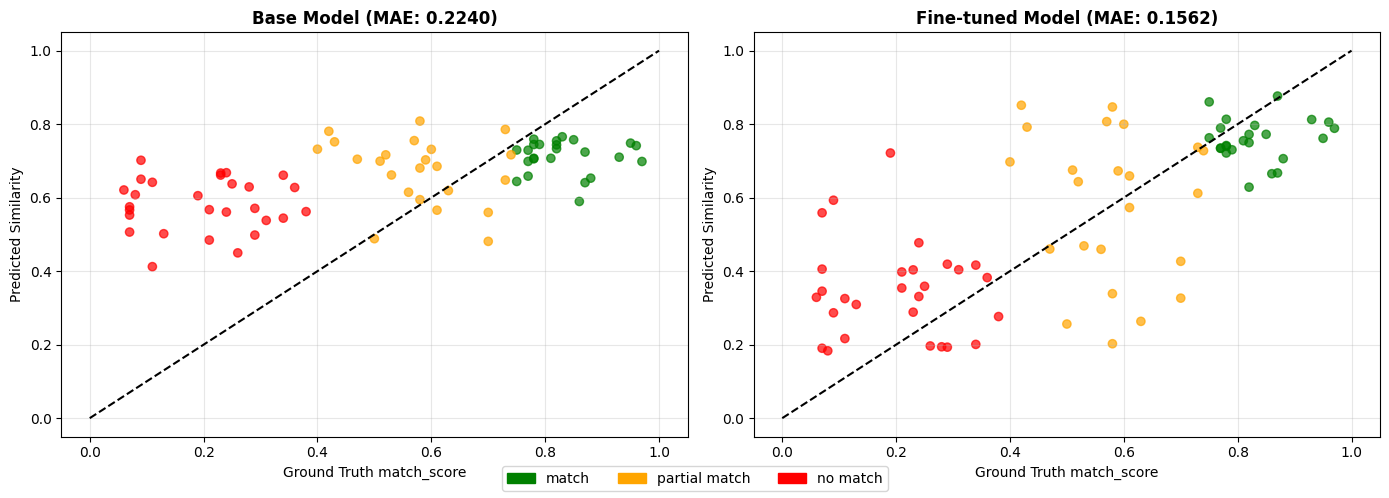

In [13]:
# Scatter plots: base vs fine-tuned :-

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = test_df['match_label'].map({'no match':'red','partial match':'orange','match':'green'})

for ax, preds, title, mae in [ (axes[0], base_preds, 'Base Model', base_mae), (axes[1], ft_preds, 'Fine-tuned Model', ft_mae) ]:
    ax.scatter(test_df['match_score'], preds, c=colors, alpha=0.7)

    ax.plot([0,1],[0,1],'k--', label='Perfect')

    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')

    ax.set_title(f'{title} (MAE: {mae:.4f})', fontweight='bold')

    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch

fig.legend(handles=[
    Patch(color='green', label='match'),
    Patch(color='orange', label='partial match'),
    Patch(color='red', label='no match'),
], loc='lower center', ncol=3)

plt.tight_layout()
plt.show()


In [14]:
# Here we are  creating and saving a metadata file that records key information about our fine‑tuning run
metadata = {
    'base_model':       'all-mpnet-base-v2',
    'dataset':          'cleaned_resumeJD_pairs.csv',
    'total_pairs':      len(df),
    'train_pairs':      len(train_df),
    'val_pairs':        len(val_df),
    'test_pairs':       len(test_df),
    'epochs':           10,
    'batch_size':       16,
    'base_mae':         round(float(base_mae), 4),
    'finetuned_mae':    round(float(ft_mae), 4),
    'improvement_pct':  round((base_mae - ft_mae) / base_mae * 100, 2),
}

# Opens a file called metadata.json inside your model folder if exists, otherwise it will firstly create this file & then open it.
# Saves the dictionary as a JSON file for future reference.
with open('models/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

#json.dump(...) :- This is a Python function from the json module. It serializes (converts) a Python object (like a dictionary or list) into a JSON‑formatted string.
# Instead of just returning the string, it writes it directly into a file object (f here).
# metadata :- This is the Python dictionary you created earlier with details about your fine‑tuning run (model name, dataset, counts, metrics, etc.).
# indent=2 :- Controls formatting of the JSON output. Instead of writing everything on one line, it pretty‑prints with indentation of 2 spaces.

print('Saved: models/finetuned-bert/')

print(json.dumps(metadata, indent=2))



Saved: models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "cleaned_resumeJD_pairs.csv",
  "total_pairs": 500,
  "train_pairs": 350,
  "val_pairs": 75,
  "test_pairs": 75,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.224,
  "finetuned_mae": 0.1562,
  "improvement_pct": 30.27
}


In [16]:
# Production Pipeline Test :-

def score_resume_against_jd(resume_text, jd_text, model):
    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd = model.encode(jd_text,     convert_to_numpy=True)

    score = cosine_similarity([emb_resume], [emb_jd])[0][0]

    return float(score)


# Test with realistic cases :-
test_cases = [
    {
        'label':  'MATCH expected',
        'resume': 'Senior Python developer with 6 years experience. Built REST APIs using FastAPI and Django. Proficient in PostgreSQL, Docker, and AWS deployment.',
        'jd':     'We need a Python backend engineer with FastAPI or Django experience. Must know SQL databases and cloud deployment.',
    },
    {
        'label':  'PARTIAL match expected',
        'resume': 'Frontend developer with 3 years React and TypeScript experience. Some Node.js and Express for small APIs.',
        'jd':     'Full stack engineer needed. React frontend required, strong Python backend preferred. 4+ years experience.',
    },
    {
        'label':  'NO match expected',
        'resume': 'Executive Chef with 12 years experience in fine dining. Expert in French cuisine, menu planning, and kitchen management.',
        'jd':     'Data Scientist with Python, machine learning, and SQL experience required.',
    },
]

print('Production Pipeline Test')
print('=' * 60)

for case in test_cases:
    score = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)
    label = 'MATCH' if score > 0.75 else 'PARTIAL' if score > 0.45 else 'NO'

    print(f"\n{case['label']}")

    print(f"Predicted score: {score:.4f}  →  {label}")


Production Pipeline Test

MATCH expected
Predicted score: 0.7533  →  MATCH

PARTIAL match expected
Predicted score: 0.7474  →  PARTIAL

NO match expected
Predicted score: 0.2434  →  NO


In [17]:
!zip -r finetuned-bert.zip models/finetuned-bert/


  adding: models/finetuned-bert/ (stored 0%)
  adding: models/finetuned-bert/model.safetensors (deflated 8%)
  adding: models/finetuned-bert/tokenizer.json (deflated 71%)
  adding: models/finetuned-bert/metadata.json (deflated 40%)
  adding: models/finetuned-bert/config_sentence_transformers.json (deflated 40%)
  adding: models/finetuned-bert/eval/ (stored 0%)
  adding: models/finetuned-bert/eval/similarity_evaluation_ats-val_results.csv (deflated 45%)
  adding: models/finetuned-bert/config.json (deflated 48%)
  adding: models/finetuned-bert/sentence_bert_config.json (deflated 43%)
  adding: models/finetuned-bert/modules.json (deflated 64%)
  adding: models/finetuned-bert/1_Pooling/ (stored 0%)
  adding: models/finetuned-bert/1_Pooling/config.json (deflated 17%)
  adding: models/finetuned-bert/tokenizer_config.json (deflated 53%)
  adding: models/finetuned-bert/README.md (deflated 74%)
  adding: models/finetuned-bert/2_Normalize/ (stored 0%)


In [18]:
from google.colab import files
files.download('finetuned-bert.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>